In [1]:
"""
Optional: Install dependencies
pip install -r requirements.txt
"""

'\nOptional: Install dependencies\npip install -r requirements.txt\n'

In [2]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
from sklearn.exceptions import ConvergenceWarning

# Setting the DataFrame up

In [3]:
dataset = fetch_ucirepo(id = 579)
X = dataset.data.features
y = dataset.data.targets['LET_IS']
df = X.join(y)
print(df.shape)
df.head()

(1700, 112)


,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS
0,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
2,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,...,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
3,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0


# Missing Values

## Basic Analysis

In [4]:
# number of missing values
df.isnull().sum().sum()

15974

In [5]:
# every row has at least one missing value
np.sum(df.T.isnull().sum()==0)

0

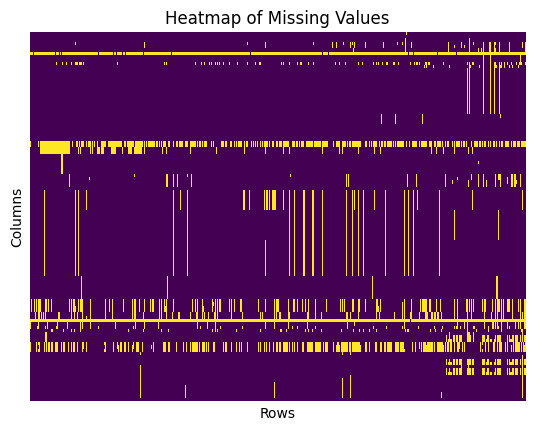

In [6]:
# missing values heatmap

plt.figure()  

# Create the heatmap
sns.heatmap(df.T.isnull(), cbar=False, cmap='viridis')

# Remove axis ticks and labels for clarity
plt.xticks(ticks=[], labels=[])
plt.yticks(ticks=[], labels=[])
plt.xlabel('Rows')
plt.ylabel('Columns')

# Add title for context
plt.title('Heatmap of Missing Values')

# Show the plot
plt.show()

In [7]:
# dropping columns where more than 25% of the values are missing
df_dropped = df.dropna(axis=1, thresh=0.75*len(df))
print(df_dropped.shape)
df_dropped.head()

(1700, 105)


,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS
0,77.0,1,2.0,1.0,1.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
2,52.0,1,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,...,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
3,68.0,0,0.0,0.0,0.0,2.0,2.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,60.0,1,0.0,0.0,0.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0


In [8]:
# dropping rows where more than 25% of the values are missing
df_shrunk = df_dropped.dropna(axis = 0, thresh = int(0.75*len(df_dropped.columns)))
df_shrunk.shape

(1624, 105)

## Identifying Data Types

In [9]:
from utils import *

In [10]:
types = data_type_classifier(df_shrunk)

In [11]:
categorical = []
binary = []
continuous = []

for key, value in types.items():
    if value == 'Categorical':
        categorical.append(key)
    elif value == 'Binary':
        binary.append(key)
    else:
        continuous.append(key)

print(f'categorical: {categorical}')
print(f'binary: {binary}')
print(f'continuous: {continuous}')

categorical: ['INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'DLIT_AG', 'ZSN_A', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'TIME_B_S', 'R_AB_1_n', 'R_AB_2_n', 'R_AB_3_n', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n', 'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'LET_IS']
binary: ['SEX', 'SIM_GIPERT', 'nr_11', 'nr_01', 'nr_02', 'nr_03', 'nr_04', 'nr_07', 'nr_08', 'np_01', 'np_04', 'np_05', 'np_07', 'np_08', 'np_09', 'np_10', 'endocr_01', 'endocr_02', 'endocr_03', 'zab_leg_01', 'zab_leg_02', 'zab_leg_03', 'zab_leg_04', 'zab_leg_06', 'O_L_POST', 'K_SH_POST', 'MP_TP_POST', 'SVT_POST', 'GT_POST', 'FIB_G_POST', 'IM_PG_P', 'ritm_ecg_p_01', 'ritm_ecg_p_02', 'ritm_ecg_p_04', 'ritm_ecg_p_06', 'ritm_ecg_p_07', 'ritm_ecg_p_08', 'n_r_ecg_p_01', 'n_r_ecg_p_02', 'n_r_ecg_p_03', 'n_r_ecg_p_04', 'n_r_ecg_p_05', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_r_ecg_p_10', 'n_p_ecg_p_01', 'n_p_ecg_p_03', 'n_p_ecg_p_04', 'n_p_ecg_p_05', 'n_p_ecg_p_06', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ec

In [12]:
print(len(categorical))
print(len(binary))
print(len(continuous))

22
74
9


## Imputation

In [13]:
from fancyimpute import KNN

### KNN

In [14]:
# KNN imputer
knn = KNN(k=4, verbose=0)
df_knn = pd.DataFrame(knn.fit_transform(df_shrunk), columns = df_shrunk.columns)
df_knn.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS
0,77.0,1.0,2.0,1.0,1.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,55.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
2,52.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,...,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3,68.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
4,60.0,1.0,0.0,0.0,0.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


Notes: KNN is extremely fast on the entire dataset.

### Iterative Imputer + Random Forest

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

In [16]:
# mappings for categorical features - we'll use these to map the imputed values back to the original values
cat_mappings = {col: df_shrunk[col].dropna().unique().tolist() for col in categorical}

# Pipelines for categorical, binary, and continuous data
cat_imputer = Pipeline(steps=[
    ('iterative_imputer', IterativeImputer(estimator=RandomForestClassifier(random_state=42), max_iter=10, random_state=42))
])

bin_imputer = Pipeline(steps=[
    ('iterative_imputer', IterativeImputer(estimator=RandomForestClassifier(random_state=42), max_iter=10, random_state=42))
])

cont_imputer = Pipeline(steps=[
    ('iterative_imputer', IterativeImputer(estimator=RandomForestRegressor(random_state=42), max_iter=10, random_state=42))
])

# combining the pipelines to fit to the dataset
transformer = ColumnTransformer(
    transformers=[
        ('categorical', cat_imputer, categorical),
        ('binary', bin_imputer, binary),
        ('continuous', cont_imputer, continuous)
    ]
)

In [17]:
# resetting the index of df_shrunk to ensure alignment
df_shrunk = df_shrunk.reset_index(drop=True)
# creating a copy so we can compare the imputed values
df_shrunk_copy = df_shrunk.copy()

# creating a mask for missing values
mask = df_shrunk.isna()

In [18]:
# supressing convergence warnings - these are expected due to the small dataset
warnings.filterwarnings(category=ConvergenceWarning, action='ignore')

# Apply the transformer to the entire DataFrame using parallel processing 
with joblib.parallel_backend('threading'):
    imputed_data = transformer.fit_transform(df_shrunk)

# converting the object to a dataframe
imputed_df = pd.DataFrame(imputed_data, columns=df_shrunk.columns)



In [19]:
# round binary predictions to 0 or 1
for column in binary:
    imputed_df[column] = (imputed_df[column] > 0.5).astype(int)

# mapping imputed categorical values back to original values
for column in categorical:
    categories = cat_mappings[column]
    imputed_df[column] = imputed_df[column].round().astype(int)
    imputed_df[column] = imputed_df[column].apply(lambda x: categories[x % len(categories)])

# adding only the imputed values back to the original dataset using the mask
for column in df_shrunk.columns:
    df_shrunk.loc[mask[column], column] = imputed_df.loc[mask[column], column]

df_shrunk.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS
0,77.0,1,2.0,1.0,1.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
2,52.0,1,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,...,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
3,68.0,0,0.0,0.0,0.0,2.0,2.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,60.0,1,0.0,0.0,0.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0


In [20]:
# checking the shape of the data
df_shrunk.shape

(1624, 105)

In [21]:
# checking for missing values
df_shrunk.isnull().sum().sum()

0

In [22]:
# creating a new dataframe for model fit 
# this is just to avoid rerunning the entire notebook to recover the dataframe
df_cleaned = df_shrunk
df_cleaned.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS
0,77.0,1,2.0,1.0,1.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
2,52.0,1,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,...,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
3,68.0,0,0.0,0.0,0.0,2.0,2.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,60.0,1,0.0,0.0,0.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0


In [23]:
# comparing IterativeImputer and KNN results
comp = (df_cleaned == df_knn)
compvals = comp.values.flatten()
print(len(compvals))
print((compvals == True).sum())
print((compvals == False).sum())

170520
166597
3923


About 75% of the imputaiton values matched up

## Data Visualization

In [24]:
# creating dataframe for features of the same data type
df_cont = df_shrunk[continuous]
df_cat = df_shrunk[categorical].drop(['LET_IS'], axis = 1)
df_bin = df_shrunk[binary]
df_cont.shape, df_cat.shape, df_bin.shape

((1624, 9), (1624, 21), (1624, 74))

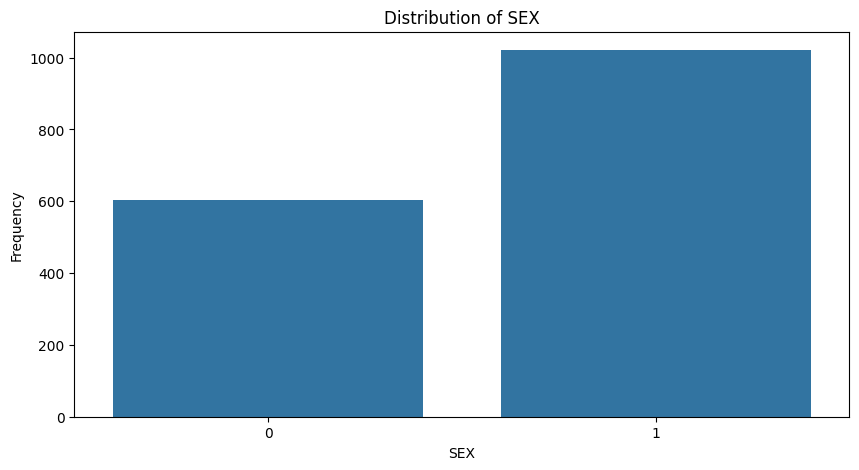

In [25]:
# creating barplots for all binary features
binary_barplots = []

for column in df_bin.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=df_bin[column].value_counts().index,
                y=df_bin[column].value_counts().values)
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    binary_barplots.append(fig)
    plt.close(fig)

binary_barplots[0]

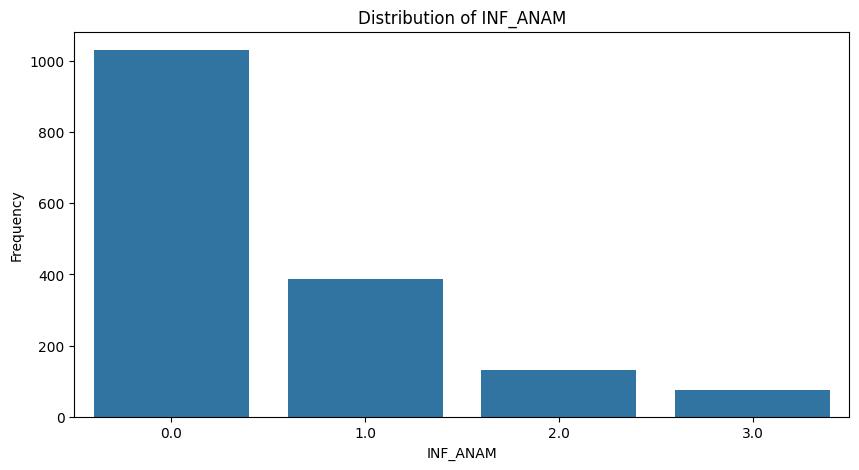

In [26]:
# creating barplots for categorical variables
categorical_barplots = []

for column in df_cat.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=df_cat[column].value_counts().index,
                y=df_cat[column].value_counts().values)
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    categorical_barplots.append(fig)
    plt.close(fig)

categorical_barplots[0]

# Correlation Analysis

In [27]:
# creating a matrix of phi coefficient correlation
phi_matrix = compute_phi_matrix(df_bin)
phi_matrix.head()

,SEX,SIM_GIPERT,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,...,GIPO_K,GIPER_NA,NITR_S,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n
SEX,1.000000,-0.068115,0.007007,-0.045380,-0.018187,-0.035144,-0.049585,0.003381,0.019704,-0.009353,...,-0.047703,0.004754,-0.050984,0.099229,0.072066,-0.031526,0.033138,-0.023089,0.023382,0.053281
SIM_GIPERT,-0.068115,1.000000,0.012868,0.057965,-0.021297,0.017778,-0.024799,-0.008205,0.049797,-0.006697,...,-0.034480,-0.026606,0.037390,-0.035073,0.043539,0.009960,-0.044638,-0.043512,0.022299,-0.000892
nr_11,0.007007,0.012868,1.000000,-0.014275,-0.017745,-0.023584,-0.020662,-0.006836,-0.008831,-0.005580,...,-0.027247,-0.022168,-0.031736,0.010692,-0.003746,0.033197,-0.006794,0.009829,0.006865,0.004880
nr_01,-0.045380,0.057965,-0.014275,1.000000,0.052623,0.034253,-0.011680,0.317979,0.119734,-0.003154,...,-0.048451,0.037967,0.055093,-0.012529,-0.035184,-0.011905,0.009999,-0.059314,-0.012531,0.037813
nr_02,-0.018187,-0.021297,-0.017745,0.052623,1.000000,-0.016572,-0.014519,0.125218,-0.006205,0.155274,...,-0.054749,-0.015577,-0.004686,-0.023113,-0.010853,0.005413,0.032499,-0.012387,-0.015577,0.010254


Text(0.5, 1.0, 'Phi Coefficient Correlation Matrix')

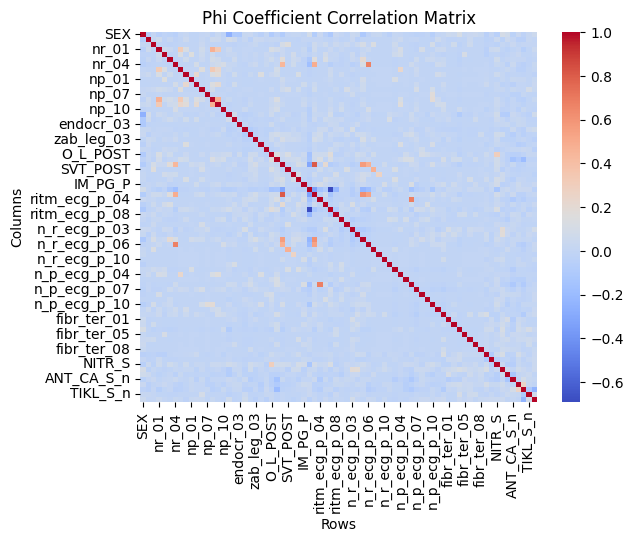

In [28]:
# correlation heatmap for binary data
plt.figure() 
sns.heatmap(phi_matrix, cbar=True, cmap='coolwarm')
plt.xlabel('Rows')
plt.ylabel('Columns')
plt.title('Phi Coefficient Correlation Matrix')

In [29]:
# creating a correlation matrix for categorical data with Cramer's V
cat_matrix = compute_cramers_v_matrix(df_cat)
cat_matrix.head()

,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,DLIT_AG,ZSN_A,ant_im,lat_im,inf_im,...,TIME_B_S,R_AB_1_n,R_AB_2_n,R_AB_3_n,NA_R_1_n,NA_R_2_n,NA_R_3_n,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n
INF_ANAM,1.000000,0.236463,0.216913,0.212145,0.072792,0.078916,0.117963,0.100301,0.082532,0.051353,...,0.102486,0.070370,0.087854,0.099207,0.074496,0.076418,0.060782,0.040475,0.048347,0.052137
STENOK_AN,0.236463,1.000000,0.482862,0.496290,0.080546,0.129211,0.100936,0.087492,0.069329,0.069242,...,0.070668,0.071911,0.085178,0.103658,0.071459,0.095524,0.091782,0.068368,0.068066,0.067758
FK_STENOK,0.216913,0.482862,1.000000,0.520911,0.120057,0.104902,0.114501,0.076324,0.058543,0.061709,...,0.074063,0.080635,0.104117,0.113918,0.054208,0.120325,0.108953,0.046023,0.060342,0.073683
IBS_POST,0.212145,0.496290,0.520911,1.000000,0.090919,0.117646,0.082727,0.098296,0.068382,0.085549,...,0.075067,0.060623,0.044054,0.063795,0.051197,0.060802,0.048155,0.035165,0.047908,0.029476
GB,0.072792,0.080546,0.120057,0.090919,1.000000,0.481145,0.053826,0.070945,0.068662,0.065536,...,0.071951,0.063306,0.032989,0.045228,0.046145,0.039339,0.054045,0.038915,0.112069,0.060057


Text(0.5, 1.0, "Cramer's V Correlation Matrix")

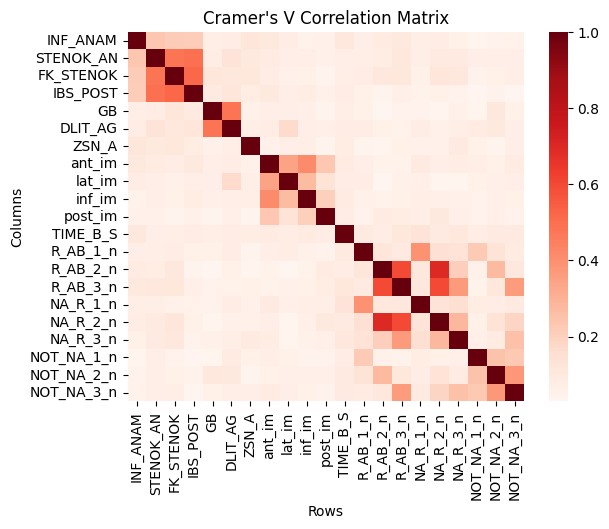

In [30]:
# creating a correlation heatmap for categorical data
plt.figure() 
sns.heatmap(cat_matrix, cbar=True, cmap='Reds')
plt.xlabel('Rows')
plt.ylabel('Columns')
plt.title('Cramer\'s V Correlation Matrix')

In [31]:
corr_matrix = df_cont.corr()
corr_matrix.head()

,AGE,S_AD_ORIT,D_AD_ORIT,K_BLOOD,NA_BLOOD,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE
AGE,1.000000,0.103165,0.067633,-0.068141,-0.059288,-0.105777,-0.060706,-0.012626,0.171149
S_AD_ORIT,0.103165,1.000000,0.964900,0.002490,0.022223,-0.060528,-0.019979,0.017868,0.037607
D_AD_ORIT,0.067633,0.964900,1.000000,0.007843,0.032932,-0.040594,-0.004208,0.025682,0.027852
K_BLOOD,-0.068141,0.002490,0.007843,1.000000,0.915471,0.157959,0.178922,0.159432,0.078809
NA_BLOOD,-0.059288,0.022223,0.032932,0.915471,1.000000,0.171498,0.185882,0.164520,0.076439


Text(0.5, 1.0, 'Pearson Correlation Matrix')

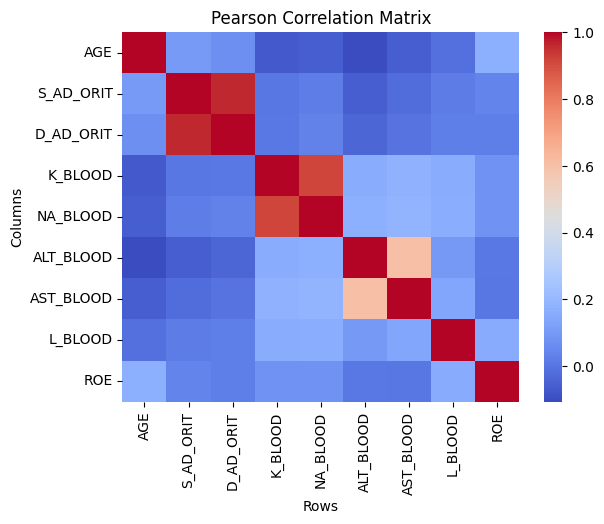

In [32]:
# creating a correlation heatmap for continuous data
plt.figure() 
sns.heatmap(corr_matrix, cbar=True, cmap='coolwarm')
plt.xlabel('Rows')
plt.ylabel('Columns')
plt.title('Pearson Correlation Matrix')

Finding the 5 most correlated features for each feature

In [33]:
bin_corrs = top_correlated_predictors_df(phi_matrix)
bin_corrs.head()

,1,2,3,4,5
SEX,endocr_01,fibr_ter_03,n_r_ecg_p_05,ritm_ecg_p_07,endocr_03
SIM_GIPERT,endocr_01,SEX,np_08,endocr_02,nr_01
nr_11,SVT_POST,n_r_ecg_p_08,n_r_ecg_p_05,MP_TP_POST,n_p_ecg_p_10
nr_01,np_08,np_09,nr_07,nr_08,O_L_POST
nr_02,np_01,nr_07,fibr_ter_05,n_p_ecg_p_04,ritm_ecg_p_06


In [34]:
cat_corrs = top_correlated_predictors_df(cat_matrix)
cat_corrs.head()

,1,2,3,4,5
INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,ZSN_A,TIME_B_S
STENOK_AN,IBS_POST,FK_STENOK,INF_ANAM,DLIT_AG,R_AB_3_n
FK_STENOK,IBS_POST,STENOK_AN,INF_ANAM,NA_R_2_n,GB
IBS_POST,FK_STENOK,STENOK_AN,INF_ANAM,DLIT_AG,ant_im
GB,DLIT_AG,FK_STENOK,NOT_NA_2_n,IBS_POST,STENOK_AN


In [35]:
cont_corrs = top_correlated_predictors_df(corr_matrix)
cont_corrs.head()

,1,2,3,4,5
AGE,ROE,ALT_BLOOD,S_AD_ORIT,K_BLOOD,D_AD_ORIT
S_AD_ORIT,D_AD_ORIT,AGE,ALT_BLOOD,ROE,NA_BLOOD
D_AD_ORIT,S_AD_ORIT,AGE,ALT_BLOOD,NA_BLOOD,ROE
K_BLOOD,NA_BLOOD,AST_BLOOD,L_BLOOD,ALT_BLOOD,ROE
NA_BLOOD,K_BLOOD,AST_BLOOD,ALT_BLOOD,L_BLOOD,ROE


# Dimensionality Reduction

In [36]:
from prince import FAMD
from sklearn.preprocessing import StandardScaler

In [37]:
# initializing FAMD model for dimensionality reduction
famd = FAMD(n_components=3, random_state=42)

In [38]:
# splitting features and target - converting target to binary
cleaned_features = df_cleaned.drop(['LET_IS'], axis = 1)
df_cleaned['LET_IS'] = df_cleaned['LET_IS'].apply(lambda x: 0 if x == 0 else 1)
target = df_cleaned['LET_IS']

In [39]:
# scaling continuous data to improve FAMD performance
scaler = StandardScaler()
cleaned_features[continuous] = scaler.fit_transform(cleaned_features[continuous])
cleaned_features.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n
0,1.294261,1,2.0,1.0,1.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-0.541005,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
2,-0.791269,1,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,...,3.0,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
3,0.543471,0,0.0,0.0,0.0,2.0,2.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4,-0.123899,1,0.0,0.0,0.0,2.0,3.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [40]:
# suppressing performance warnings - these are expected due to the small dataset
warnings.filterwarnings(category=PerformanceWarning, action='ignore')

# principal components
df_famd = pd.DataFrame(famd.fit_transform(cleaned_features))
df_famd.head()

component,0,1,2
0,2.114576,1.075584,-0.644847
1,-2.354053,-0.605948,2.133534
2,0.001045,-3.788038,2.764661
3,-0.849466,0.145219,-0.241758
4,-0.718223,0.346710,-0.193776


Text(0.5, 0, 'FAMD3')

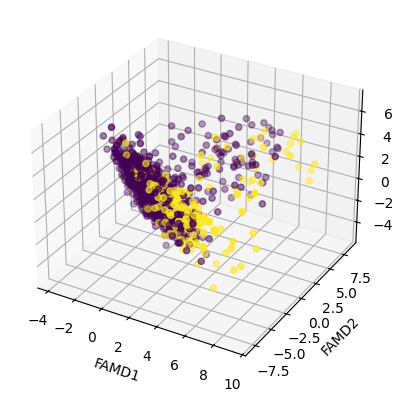

In [41]:
# plot of principal components
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df_famd.iloc[:,0], df_famd.iloc[:,1], df_famd.iloc[:,2], c = target)
ax.set_xlabel('FAMD1')
ax.set_ylabel('FAMD2')
ax.set_zlabel('FAMD3')

### For loop to plot Number of Components vs. Cumulative Explained Variance

In [42]:
# supressing performance warnings - these are expected due to the small dataset
warnings.filterwarnings(category=PerformanceWarning, action='ignore')

components = [i for i in range(1, 51)]
vars = []
for i in components:
    famd = FAMD(n_components=i, random_state=42)
    famd.fit_transform(cleaned_features)
    vars.append(famd._eigenvalues_summary.iloc[i-1,2])

Text(0.5, 1.0, 'Cumulative Explained Variance vs. Number of Components')

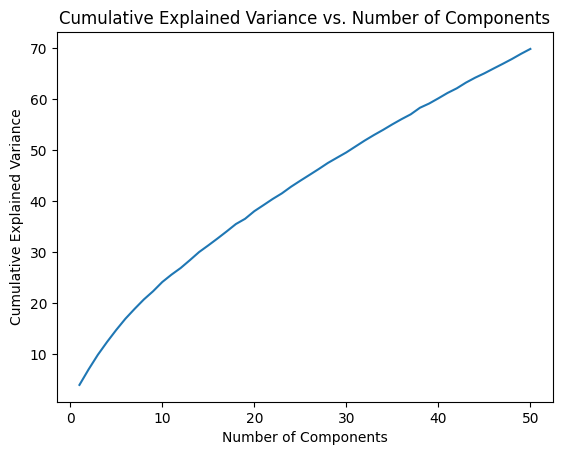

In [43]:
fig, ax = plt.subplots()
ax.plot(components, vars)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance vs. Number of Components')

In [44]:
# supressing performance warnings - these are expected due to the small dataset
warnings.filterwarnings(category=PerformanceWarning, action='ignore')

# dimensionality reduction to 10 components
famd_10 = FAMD(n_components=10, random_state=42)
features_10 = famd_10.fit_transform(cleaned_features)
# looking at the loading vectors
famd_10.column_contributions_

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
AGE,0.039038,0.004988,0.017157,0.007244,0.000131,0.001865,0.007275,0.002050,0.000749,3.916510e-03
INF_ANAM,0.027671,0.004841,0.024835,0.000014,0.000074,0.001835,0.002102,0.028253,0.019049,3.216156e-04
STENOK_AN,0.047705,0.001403,0.040756,0.005402,0.000186,0.002643,0.006475,0.106281,0.002801,1.466563e-02
FK_STENOK,0.054502,0.002073,0.045449,0.005930,0.000050,0.001154,0.006332,0.088632,0.001194,1.286775e-02
IBS_POST,0.012017,0.001483,0.044330,0.001640,0.003291,0.003320,0.009165,0.074933,0.000289,3.586846e-04
...,...,...,...,...,...,...,...,...,...,...
GEPAR_S_n,0.001589,0.003362,0.020831,0.018181,0.012918,0.001134,0.000025,0.004178,0.018757,3.980529e-04
ASP_S_n,0.006098,0.000495,0.000365,0.028878,0.000254,0.000443,0.000496,0.000570,0.044787,4.247324e-03
TIKL_S_n,0.000689,0.000136,0.001551,0.001191,0.000216,0.000293,0.005227,0.001388,0.001066,7.099496e-07


# Model Fit

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, GridSearchCV

In [46]:
def fit(features, target, components, method):
    # reducing data with FAMD
    famd = FAMD(n_components=components, random_state=42)
    features_reduced = famd.fit_transform(features)

    # converting method parameter to lowercase for exception handling
    method = method.lower()

    # training/testing process for xgboost
    if method == 'xgboost':
        xgb = XGBClassifier()

        # performing grid search for optimal parameters
        params = {
            'n_estimators': np.arange(100, 501, 50),
            'max_depth': np.arange(1, 11, 1),
            'learning_rate': np.arange(0.01, 0.1, 0.01),
            'random_state': [42]
        }

        grid = GridSearchCV(estimator=xgb, 
                            param_grid=params,
                            scoring='accuracy', 
                            n_jobs=-1,
                            cv=10, 
                            verbose=1
                           )
        grid.fit(features_reduced, target)

        # extracting optimal model
        optimal_estimator = grid.best_estimator_
        print(optimal_estimator)
    
        # running 10-fold Stratified CV with the best estimator
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

        # initializing lists to hold data from each fold
        conf_matrix_vals = []
        y_test_vals = []
        y_preds = []

        # fitting model to training data for each fold - and generating predictions
        for train_index, test_index in skf.split(features_reduced, target):
            # splitting into train and test sets
            X_train, X_test = features_reduced.iloc[train_index], features_reduced.iloc[test_index]
            y_train, y_test = target.iloc[train_index], target.iloc[test_index]

            # fitting the model and generating predictions
            optimal_estimator.fit(X_train, y_train)
            preds = optimal_estimator.predict(X_test)

            # appending test data and predictions for each fold to the lists
            y_preds.extend(preds)
            y_test_vals.extend(y_test)

            # appending confusion matrices for each fold to a list
            matrix = confusion_matrix(y_test, preds)
            conf_matrix_vals.append(matrix)

        # summing the confusion matrices from each fold
        conf_matrix = np.sum(conf_matrix_vals, axis=0)

        # creating a confusion matrix display 
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
        disp.plot()
        plt.show()

        report = classification_report(y_true=y_test_vals, y_pred=y_preds, target_names=['0', '1'])
        
        # Get the feature importances from the optimal model
        feature_importances = optimal_estimator.feature_importances_

        # Plotting the feature importances
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(feature_importances)), feature_importances, tick_label=[f'FAMD {i+1}' for i in range(len(feature_importances))])
        plt.ylabel('Importance')
        plt.title('Feature Importances in Optimal XGBClassifier')
        plt.show()

        print(report)


Fitting 10 folds for each of 810 candidates, totalling 8100 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06999999999999999,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)


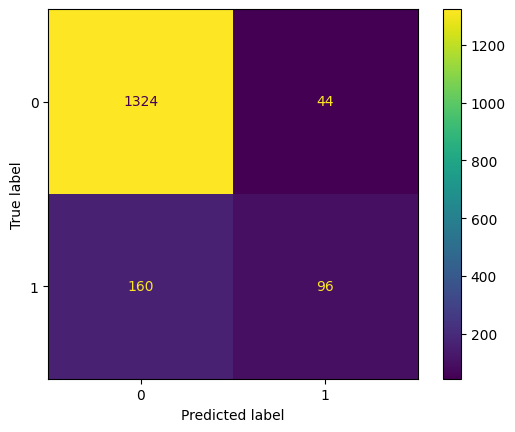

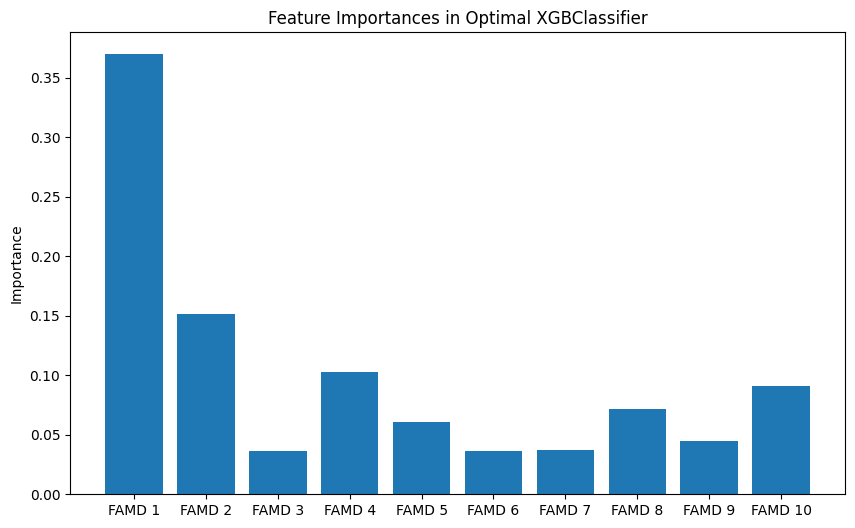

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1368
           1       0.69      0.38      0.48       256

    accuracy                           0.87      1624
   macro avg       0.79      0.67      0.71      1624
weighted avg       0.86      0.87      0.86      1624



In [47]:
# filtering out performance warnings - these are expected due to the small dataset
warnings.filterwarnings(category=PerformanceWarning, action='ignore')

fit(cleaned_features, df_cleaned['LET_IS'], 10, 'xgboost')